# **Sesión 4:** Procesamiento de imagenes y extracción de características

## **Librerías**

In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

## **Apartado A:** Detección de lineas rectas
El objetivo de este apartado es la detección de líneas y bordes en las imágenes de la carpeta `data/partA`.
1. **Tarea A.1.** Aplique `cv2.Canny()` a las imágenes de trabajo ajustando los hiperparámetros.
3. **Tarea A.2.** Implemente la función `draw_lines()` para pintar las líneas sobre las imágenes.
4. **Tarea A.3.** Aplique Hough con `cv2.HoughLinesP()` a las imágenes de trabajo para extraer líneas y afine los hiperparámetros.
5. **Problema A.1.** Repita el procedimiento para extraer las líneas de las dos imágenes restantes.

### **NOTA**
Podéis usar el mismo formato de guardado de resultados y nomenclatura que en en las práctica 3 o hacer uso de la funcion `show_image()` del Lab 1. Usad las herramientas con las que os sintáis más cómodos

In [2]:
def load_image(image_path):
    """Load an image from the specified path."""
    return cv2.imread(image_path)

def show_image(window_name, image):
    """Display an image in a window."""
    cv2.imshow(window_name, image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

def write_image(img, output_folder, filename):
    os.makedirs(output_folder, exist_ok=True) 
    img_path = os.path.join(output_folder, filename)
    cv2.imwrite(img_path, img)

imgs = []
for i in range(4):
    if i  == 0:
        imgs.append(load_image(f"../data/partA/{i}.jpg"))
    else:
        imgs.append(load_image(f"../data/partA/{i}.png"))

# Definimos la lista con las dos primeras imágenes
imgs_A_first2 = [imgs[0], imgs[1]]

# Definimos la lista con las dos últimas imágenes
imgs_A_last2 = [imgs[2], imgs[3]]


### **Tarea A.1.** Aplique `cv2.Canny()` a las imágenes de trabajo ajustando los hiperparámetros

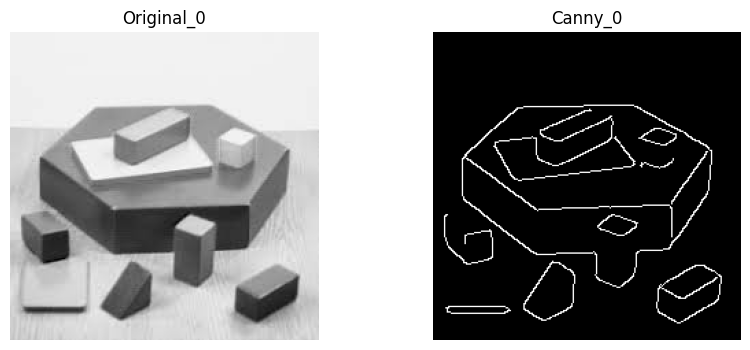

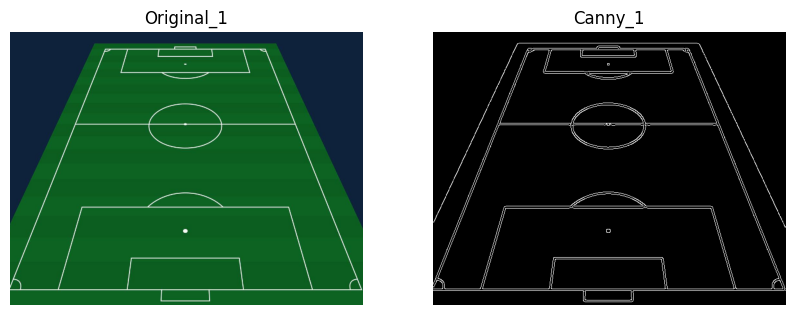

In [ ]:
# TODO Apply canny to the images, play with the thresholds to get a good result

edge_imgs = []  # to store the canny edge images for later Hough transform

# 1st image
img1 = imgs_A_first2[0]

# Convert to grayscale
gray_img = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

# La pasamos por filtro gaussiano primero. 
blur = cv2.GaussianBlur(gray_img, (5, 5), 1.4)

# Hyperparameters
low_threshold = 100
high_threshold = 2 * low_threshold

# Apply Canny edge detection
edge_img = cv2.Canny(blur, low_threshold, high_threshold)

# Store the edge image for later Hough transform
edge_imgs.append(edge_img)
...

# Display the image or save it as you like
show_image("original image", img1)
show_image("edge image", edge_img)

# 2nd image

img2 = imgs_A_first2[1]
low_threshold = 50 # con menos thereshold se ven igual de bien las lineas. 
high_threshold = 2 * low_threshold

gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
blur2 = cv2.GaussianBlur(gray_img2, (5, 5), 1.4)

edge_img2 = cv2.Canny(blur2, low_threshold, high_threshold)
edge_imgs.append(edge_img2)

show_image("original image 2", img2)
show_image("edge image 2", edge_img2)

# Definimos una lista con las dos imagenes de bordes
edge_imgs_first2 = [edge_imgs[0], edge_imgs[1]]

# GUARDAR RESULTADOS CANNY

output_dir = "T_A1_Canny"
os.makedirs(output_dir, exist_ok=True)  # crea la carpeta si no existe

# Guardamos las imágenes de bordes
cv2.imwrite(os.path.join(output_dir, "edge_image_1.png"), edge_img)
cv2.imwrite(os.path.join(output_dir, "edge_image_2.png"), edge_img2)

def show_two_images(original_img, canny_img, idx):

    plt.figure(figsize=(10, 4))

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original_{idx}")
    plt.axis("off")

    # Canny
    plt.subplot(1, 2, 2)
    plt.imshow(canny_img, cmap="gray")
    plt.title(f"Canny_{idx}")
    plt.axis("off")

    plt.show()

for i in range(2):
    show_two_images(
        original_img = imgs_A_first2[i],
        canny_img    = edge_imgs_first2[i],
        idx = i)


### **Tarea A.2.** Implemente `draw_lines()` para pintar las lineas sobre cada imagen

In [4]:
# TODO Draw the lines on the images. A line is a tuple of 4 integers (x1, y1, x2, y2) where (x1, y1) and (x2, y2) are the coordinates of the two points of the line.
def draw_lines(img, lines, color, thickness):

    img_with_lines = img.copy()
    for line in lines:
        # Algunas implementaciones devuelven [[x1, y1, x2, y2]], otras [x1, y1, x2, y2]
        x1, y1, x2, y2 = line[0]
        cv2.line(img_with_lines, (x1, y1), (x2, y2), color, thickness)

    return img_with_lines

### **Tarea A.3.** Aplique Hough con `cv2.HoughLinesP()` a las imágenes de trabajo para extraer líneas y afine los hiperparámetros

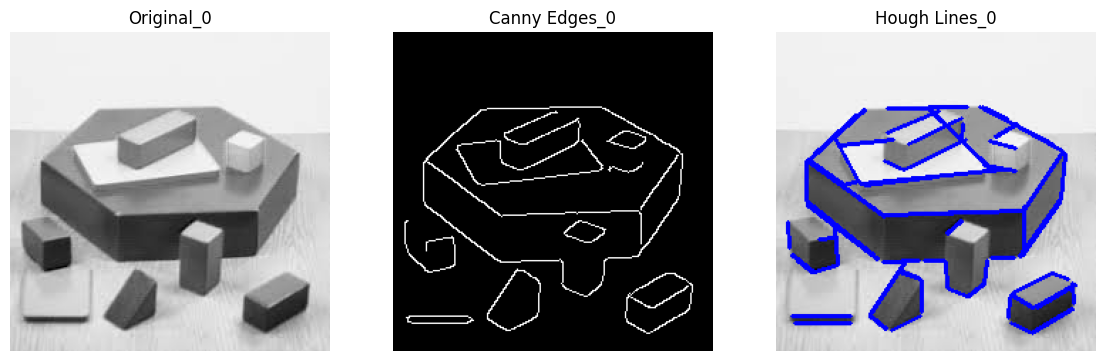

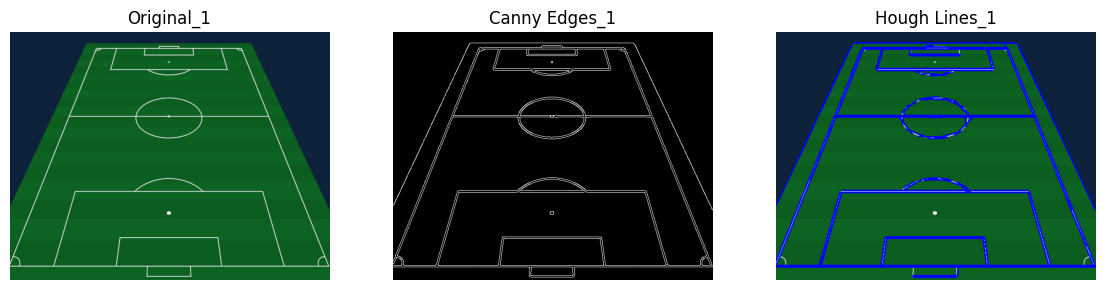

 Imágenes guardadas correctamente en: T_A3_Hough_Lines


In [5]:
# TODO Apply the hough transform to the images, play with the parameters to get a good result

# 1st image

# Define the hough transform parameters

# Resolución en píxeles (distancia)
rhos = [1, 1]      
# Resolución angular (1 grado)
thetas = [np.pi / 180, np.pi / 180] 
# Número mínimo de votos (ajustable)                 
thresholds = [15, 15]           
# Longitud mínima de línea aceptada   
min_line_lengths = [10, 10]    
# Máxima separación entre segmentos para unirlos   
max_line_gaps = [10, 10] 

# Get the edge images
edges = edge_imgs_first2.copy()

# Apply the hough transform
lines1 = cv2.HoughLinesP(edges[0], rhos[0], thetas[0], thresholds[0], minLineLength=min_line_lengths[0], maxLineGap=max_line_gaps[0])

# Draw the lines on the image (on the original image, make sure to get a copy, as draw_lines modifies the image)
img_with_lines_1 = draw_lines(imgs_A_first2[0], lines1, color=(255, 0, 0), thickness=2)

# 2nd image
# Apply the hough transform
lines2 = cv2.HoughLinesP(edges[1], rhos[1], thetas[1], thresholds[1], minLineLength=min_line_lengths[1], maxLineGap=max_line_gaps[1])

# Draw the lines on the image (on the original image, make sure to get a copy, as draw_lines modifies the image)
img_with_lines_2 = draw_lines(imgs_A_first2[1], lines2, color=(255, 0, 0), thickness=2)

# Creamos una lista con las imágenes con líneas
imgs_with_lines = [img_with_lines_1, img_with_lines_2]

# Show the image or save it as you like

def show_three_images(original_img, edges_img, hough_img, idx):

    plt.figure(figsize=(14, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Original_{idx}")
    plt.axis("off")

    # Canny
    plt.subplot(1, 3, 2)
    plt.imshow(edges_img, cmap="gray")
    plt.title(f"Canny Edges_{idx}")
    plt.axis("off")

    # Hough
    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(hough_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Hough Lines_{idx}")
    plt.axis("off")

    plt.show()

# Bucle para mostrar las dos imágenes con Original, Canny y Hough
for i in range(2):
    show_three_images(
        original_img = imgs_A_first2[i],
        edges_img    = edge_imgs_first2[i],
        hough_img    = img_with_lines_1 if i == 0 else img_with_lines_2,
        idx          = i
    )

output_folder = "T_A3_Hough_Lines"

for i, img in enumerate(imgs_with_lines):
    write_image(img, output_folder, f"A3_Hough_Lines_{i}.png")

print(" Imágenes guardadas correctamente en:", output_folder)




### **Problema A.1.** Repita el procedimiento para extraer las líneas de las dos imágenes restantes

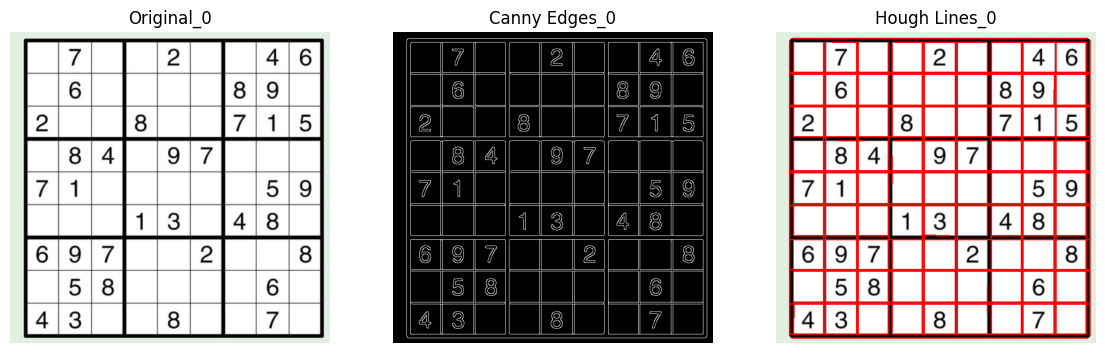

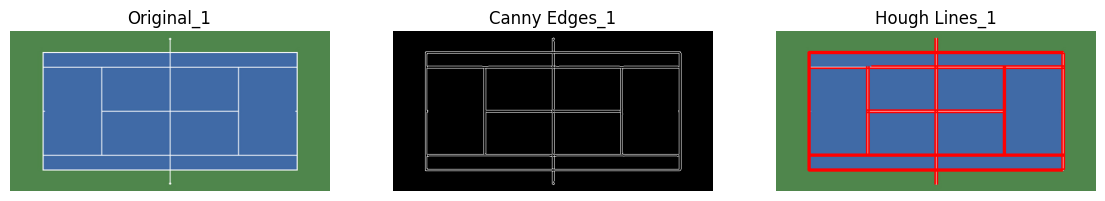

 Las imágenes dos últimas imágenes de Hough fueron guardadas en: T_A3_Hough_Lines


In [17]:
# TODO Homework

# Resolución en píxeles (distancia)
rhos = [2, 1]      
# Resolución angular (1 grado)
theta = np.pi / 180 
# Número mínimo de votos (ajustable)                 
thresholds = [80, 80]       
# Longitud mínima de línea aceptada   
min_line_lengths = [50, 60]    
# Máxima separación entre segmentos para unirlos   
max_line_gapss = [10, 8]

# Lista donde guardaremos las imágenes con líneas
imgs_with_lines_rest = []

low_thresholds = [100, 50]

# Repetir para las imágenes con índices 2 y 3
for i in range(2):

    # 1. Aplicar Canny
    # Convertir a escala de grises
    gray = cv2.cvtColor(imgs_A_last2[i], cv2.COLOR_BGR2GRAY)

    # Suavizado GaussianBlur 

    blur = cv2.GaussianBlur(gray, (5, 5), 1.4)
    
    # cogemos el low_threshold de la lista 
    low_threshold = low_thresholds[i]
    high_threshold = 2* low_threshold

    # Canny
    edges = cv2.Canny(blur, low_threshold, high_threshold)

    # 2. Aplicar HoughLinesP
    
    # Usamos los mismos parámetros que antes
    lines = cv2.HoughLinesP(
        edges,
        rho=rhos[i],
        theta=theta,
        threshold=thresholds[i],
        minLineLength=min_line_lengths[i],
        maxLineGap=max_line_gapss[i]
    )

    # 3. Dibujar líneas
    img_with_lines = draw_lines(
        imgs_A_last2[i], 
        lines, 
        color=(0, 0, 255), 
        thickness=2
    )
    
    imgs_with_lines_rest.append(img_with_lines)

    # 4. Mostrar resultados
    show_three_images(
        original_img = imgs_A_last2[i],
        edges_img    = edges,
        hough_img    = img_with_lines,
        idx          = i
    )

output_folder = "T_A3_Hough_Lines"

for i, img in enumerate(imgs_with_lines_rest):
    real_index = i + 2
    write_image(img, output_folder, f"A3_Hough_Lines_rest_{real_index}.png")

print(" Las imágenes dos últimas imágenes de Hough fueron guardadas en:", output_folder)